## Crucial imports

In [202]:
import webdataset as wds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data Preparation

### Read data to dataframme 
we dont need id so Image Index is id (name of the photo e.g. 00001.png )

In [203]:
df = pd.read_csv("Data_Entry_2017.csv")
df = df.set_index('Image Index')
print(df.head(3))


                          Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                                     
00000001_000.png            Cardiomegaly            0           1        058Y   
00000001_001.png  Cardiomegaly|Emphysema            1           1        058Y   
00000001_002.png   Cardiomegaly|Effusion            2           1        058Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00000001_000.png              M            PA                 2682     2749   
00000001_001.png              M            PA                 2894     2729   
00000001_002.png              M            PA                 2500     2048   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00000001_000.png                        0.143  0.143          

### Function to process sample

taking 1000 images and returning for it:
* image_data = data for pixels
* clean_key = name of the photo without folder name
* label = name of the disease

In [204]:
def process_sample(sample):

    image_data = sample['png']
    full_key = sample["__key__"]
    clean_key = full_key.replace("images/", "") + ".png"
    label = df.at[clean_key, 'Finding Labels']

    return image_data, clean_key, label


url = "images/images_{001..012}.tar.gz"
dataset = (
    wds.WebDataset(url,shardshuffle=False)
    .shuffle(1000)
    .decode("torchrgb")
    .map(process_sample)
)


for (image, key, label) in dataset:
    print(f"key={key}, image shape={image.shape}, label={label}")
    break

key=00000337_000.png, image shape=torch.Size([3, 1024, 1024]), label=Atelectasis|Effusion|Mass


## Display three random samples

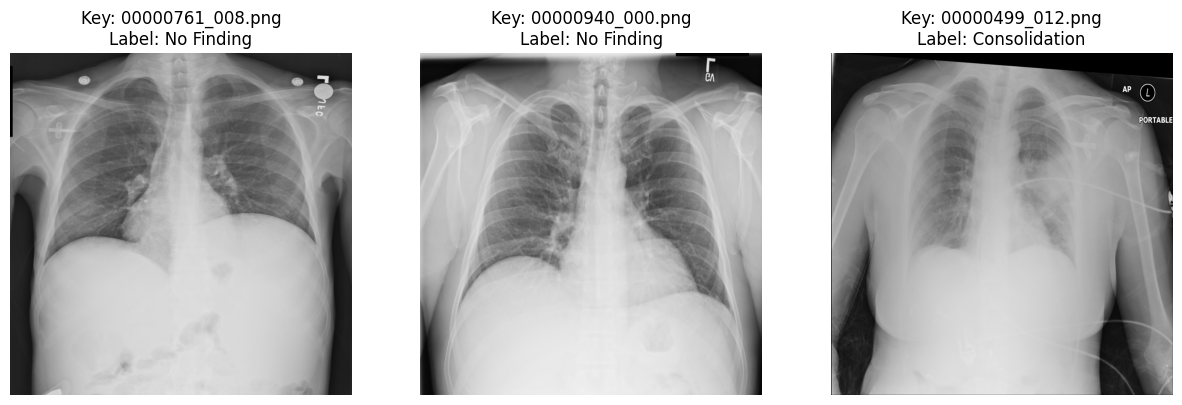

In [205]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sample_iter = iter(dataset)

for i in range(3):
    image_tensor, key, label = next(sample_iter)
    img = image_tensor.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(f"Key: {key}\nLabel: {label[:20]}")
    axes[i].axis('off')

plt.show()